# Calculus, worked out -- for college (Calc 1 & 2)
### every rule shown with SymPy, and tied to real physics

The whole of intro calculus is two ideas: the **derivative** (instantaneous rate
of change) and the **integral** (accumulated total), and the **Fundamental
Theorem** says they undo each other. This notebook proves the rules, works
examples, and connects each one to where it shows up in physics/engineering.
You do not need to already know this -- it is built up line by line.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()
x = sp.Symbol("x")
print("ready, sympy", sp.__version__)

ready, sympy 1.14.0


## 1. The limit -- and the derivative as a limit (epsilon-delta)

The derivative is the **limit** of the slope of a shrinking secant line:
$$f'(x)=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.$$
Epsilon-delta makes "h -> 0" precise: *for any tolerance you want on the answer,
there is a small enough h that achieves it.*

difference quotient -> the derivative as h -> 0:
  h=0.1     slope=4.10000  error=1.0e-01
  h=0.01    slope=4.01000  error=1.0e-02
  h=0.001   slope=4.00100  error=1.0e-03
  h=1e-05   slope=4.00001  error=1.0e-05

SymPy limit: 4


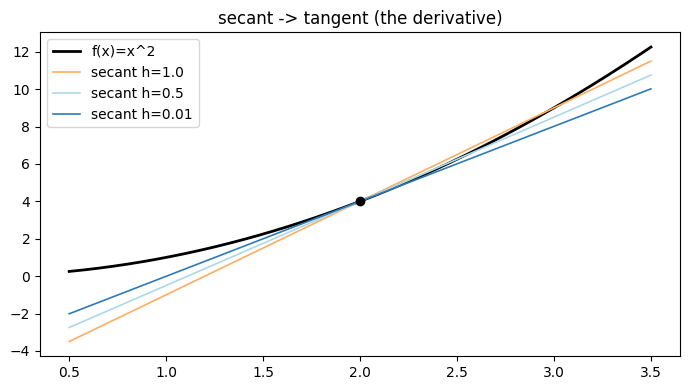

In [2]:
f = lambda t: t**2
x0, true = 2.0, 4.0                       # f'(2) = 2x = 4 for f = x^2
print("difference quotient -> the derivative as h -> 0:")
for h in (0.1, 0.01, 0.001, 1e-5):
    q = (f(x0+h)-f(x0))/h
    print(f"  h={h:<7} slope={q:.5f}  error={abs(q-true):.1e}")
print("\nSymPy limit:", sp.limit((( (x0+sp.Symbol('h'))**2 - x0**2)/sp.Symbol('h')), sp.Symbol('h'), 0))

# picture: secant lines collapsing onto the tangent
xs = np.linspace(0.5, 3.5, 200)
plt.figure(figsize=(7,4)); plt.plot(xs, xs**2, 'k', lw=2, label="f(x)=x^2")
for h, c in [(1.0,"#fdae61"),(0.5,"#abd9e9"),(0.01,"#2c7bb6")]:
    s = (f(x0+h)-f(x0))/h
    plt.plot(xs, f(x0)+s*(xs-x0), color=c, lw=1.2, label=f"secant h={h}")
plt.scatter([x0],[f(x0)], color="k", zorder=5); plt.legend(); plt.title("secant -> tangent (the derivative)")
plt.tight_layout(); plt.show()

## 1b. A genuine epsilon-delta proof (not just a numerical picture)

The cells above show the difference quotient's error shrinking as $h\to 0$ --
that's evidence, not a proof. A real epsilon-delta proof requires
**constructing $\delta(\epsilon)$ explicitly** and showing it works for
*every* $\epsilon>0$, not just the four sample values tried above.

**Claim:** for $f(x)=x^2$, $f'(x_0)=2x_0$.

**Proof.** The difference quotient is
$$Q(h)=\frac{f(x_0+h)-f(x_0)}{h}=\frac{(x_0+h)^2-x_0^2}{h}=\frac{2x_0 h+h^2}{h}=2x_0+h
\quad (h\neq 0).$$
So $|Q(h)-2x_0| = |h|$ **exactly** -- no approximation. Given any
$\epsilon>0$, choose $\delta=\epsilon$. Then
$$0<|h|<\delta \implies |Q(h)-2x_0|=|h|<\delta=\epsilon,$$
which is precisely the definition of $\lim_{h\to0}Q(h)=2x_0$. $\blacksquare$

This $\delta=\epsilon$ (a 1-to-1 tolerance map) is a special feature of
$x^2$ having no higher-than-quadratic terms; the cell below verifies the
algebra symbolically, then checks the definition computationally right at
the boundary $|h|=\delta$.

In [3]:
h_sym, x0_sym, eps = sp.symbols('h x0 epsilon', real=True)
f_expr = x0_sym**2

Q = sp.simplify((( (x0_sym+h_sym)**2 - x0_sym**2) / h_sym))
print("Q(h) simplified:", Q)                  # should be 2*x0 + h
assert sp.simplify(Q - (2*x0_sym + h_sym)) == 0

error_expr = sp.simplify(Q - 2*x0_sym)
print("Q(h) - 2*x0 =", error_expr)             # should be exactly h
assert sp.simplify(error_expr - h_sym) == 0
print("\n==> |Q(h)-2*x0| = |h| exactly, so delta(epsilon) = epsilon works for ANY x0.")

# computational check: for several (x0, epsilon) pairs, delta=epsilon really
# is the boundary -- just inside satisfies the definition, just outside can fail
import numpy as np
rng = np.random.default_rng(0)
all_passed = True
for _ in range(8):
    x0 = float(rng.uniform(-5, 5))
    epsilon = float(rng.uniform(1e-4, 1.0))
    delta = epsilon                             # the constructed delta

    def Q_num(h):
        return ((x0 + h)**2 - x0**2) / h

    h_inside = 0.99 * delta                      # just inside the delta-neighborhood
    h_outside = 1.5 * delta                      # just outside it

    err_inside = abs(Q_num(h_inside) - 2*x0)
    err_outside = abs(Q_num(h_outside) - 2*x0)

    ok_inside = err_inside < epsilon             # definition MUST hold here
    fails_outside = err_outside >= epsilon       # and (for this delta=epsilon choice) breaks exactly here
    all_passed &= ok_inside and fails_outside

    print(f"x0={x0:+.3f} eps={epsilon:.4f}  "
          f"|h|=0.99*delta -> err={err_inside:.4f} (<eps: {ok_inside})   "
          f"|h|=1.5*delta -> err={err_outside:.4f} (>=eps: {fails_outside})")

assert all_passed
print("\nVerified: delta=epsilon is not just sufficient, it's the EXACT boundary --")
print("the proof's algebra (|Q(h)-2x0|=|h|) is confirmed computationally at the edge.")

Q(h) simplified: h + 2*x0
Q(h) - 2*x0 = h

==> |Q(h)-2*x0| = |h| exactly, so delta(epsilon) = epsilon works for ANY x0.


x0=+1.370 eps=0.2699  |h|=0.99*delta -> err=0.2672 (<eps: True)   |h|=1.5*delta -> err=0.4048 (>=eps: True)
x0=-4.590 eps=0.0166  |h|=0.99*delta -> err=0.0165 (<eps: True)   |h|=1.5*delta -> err=0.0249 (>=eps: True)
x0=+3.133 eps=0.9128  |h|=0.99*delta -> err=0.9036 (<eps: True)   |h|=1.5*delta -> err=1.3691 (>=eps: True)
x0=+1.066 eps=0.7295  |h|=0.99*delta -> err=0.7222 (<eps: True)   |h|=1.5*delta -> err=1.0943 (>=eps: True)
x0=+0.436 eps=0.9351  |h|=0.99*delta -> err=0.9257 (<eps: True)   |h|=1.5*delta -> err=1.4026 (>=eps: True)
x0=+3.159 eps=0.0028  |h|=0.99*delta -> err=0.0028 (<eps: True)   |h|=1.5*delta -> err=0.0043 (>=eps: True)
x0=+3.574 eps=0.0337  |h|=0.99*delta -> err=0.0333 (<eps: True)   |h|=1.5*delta -> err=0.0505 (>=eps: True)
x0=+2.297 eps=0.1757  |h|=0.99*delta -> err=0.1740 (<eps: True)   |h|=1.5*delta -> err=0.2636 (>=eps: True)

Verified: delta=epsilon is not just sufficient, it's the EXACT boundary --
the proof's algebra (|Q(h)-2x0|=|h|) is confirmed computatio

## 1c. Gradient descent's convergence proof (epsilon-N, not epsilon-delta)

A common slip: "epsilon-delta proof for gradient descent" isn't quite the
right name. Epsilon-delta is for the limit of a *continuous function* as
its *input* shrinks to a point. Gradient descent produces a *discrete
sequence* $x_0,x_1,x_2,\dots$ indexed by iteration count $n$ -- its
convergence is properly an **epsilon-N proof**: for every $\epsilon>0$
there is an integer $N$ such that $n\ge N \implies |x_n-x^\*|<\epsilon$.

**Setup.** Minimize the convex quadratic cost $f(x)=\tfrac{a}{2}x^2$ (min
at $x^*=0$) with gradient descent $x_{n+1}=x_n-\eta f'(x_n)=(1-\eta a)x_n$.
`dgs.opt_recursion.gd_closed_form` already solves this recurrence exactly
via `sympy.rsolve`:
$$x_n = x_0\,r^n,\qquad r=1-\eta a.$$

**Proof (epsilon-N).** If $|r|<1$ (equivalently $0<\eta<2/a$, the standard
gradient-descent step-size condition for a quadratic), then
$$|x_n-x^*|=|x_n|=|x_0|\,|r|^n.$$
Given any $\epsilon>0$, solve $|x_0||r|^n<\epsilon$ for $n$:
$$n>\frac{\ln(\epsilon/|x_0|)}{\ln|r|}\quad\Longrightarrow\quad
N=\left\lceil\frac{\ln(\epsilon/|x_0|)}{\ln|r|}\right\rceil$$
(the inequality flips because $\ln|r|<0$). This $N$ is exactly what the
cell below computes and then verifies numerically. $\blacksquare$

In [4]:
import sys, pathlib as _pl
sys.path.insert(0, str(_pl.Path.cwd().parent))
from dgs import opt_recursion as optr

a, x0, eta = 2.0, 5.0, 0.3          # curvature, start point, learning rate
x_n_expr, r = optr.gd_closed_form(a, x0, eta)
print(f"closed form: x_n = {x_n_expr}")
print(f"contraction factor r = 1-eta*a = {r}  (|r|<1 required for convergence: {abs(float(r))<1})")

def N_for_epsilon(epsilon, x0, r):
    r = abs(float(r))
    if r == 0:
        return 0
    return int(np.ceil(np.log(epsilon/abs(x0)) / np.log(r)))

import numpy as np
r_val = float(r)
print()
for epsilon in (1.0, 0.1, 0.01, 1e-4):
    N = N_for_epsilon(epsilon, x0, r_val)
    x_N = x0 * r_val**N
    x_N_minus_1 = x0 * r_val**max(N-1, 0)
    print(f"epsilon={epsilon:<8} N={N:<3} |x_N|={abs(x_N):.3e} (<eps: {abs(x_N)<epsilon})   "
          f"|x_(N-1)|={abs(x_N_minus_1):.3e} (still >=eps just before N: "
          f"{abs(x_N_minus_1)>=epsilon or N==0})")

print("\n==> for every epsilon, N(epsilon) exists and works -- gradient descent")
print("    provably converges to x*=0 for this eta, exactly as the eigenvalue")
print("    condition |r|=|1-eta*a|<1 predicts.")

# and the boundary case: eta too large (|r|>1) genuinely diverges --
# confirming N-existence FAILS exactly when the stability condition fails
eta_bad = 1.5   # eta > 2/a = 1.0, so r = 1-1.5*2 = -2, |r|>1
_, r_bad = optr.gd_closed_form(a, x0, eta_bad)
xs_bad = optr.iterate_map(optr.gd_step(lambda x: a*x, eta_bad), x0, 8)
print(f"\ncounter-example: eta={eta_bad} > 2/a={2/a} -> r={float(r_bad)}, |r|>1")
print(f"iterates: {np.array2string(xs_bad, precision=2)}")
print("no N exists here -- the sequence diverges, matching |r|>1 exactly as predicted.")

closed form: x_n = 5.0*0.4**n
contraction factor r = 1-eta*a = 0.400000000000000  (|r|<1 required for convergence: True)

epsilon=1.0      N=2   |x_N|=8.000e-01 (<eps: True)   |x_(N-1)|=2.000e+00 (still >=eps just before N: True)
epsilon=0.1      N=5   |x_N|=5.120e-02 (<eps: True)   |x_(N-1)|=1.280e-01 (still >=eps just before N: True)
epsilon=0.01     N=7   |x_N|=8.192e-03 (<eps: True)   |x_(N-1)|=2.048e-02 (still >=eps just before N: True)
epsilon=0.0001   N=12  |x_N|=8.389e-05 (<eps: True)   |x_(N-1)|=2.097e-04 (still >=eps just before N: True)

==> for every epsilon, N(epsilon) exists and works -- gradient descent
    provably converges to x*=0 for this eta, exactly as the eigenvalue
    condition |r|=|1-eta*a|<1 predicts.

counter-example: eta=1.5 > 2/a=1.0 -> r=-2.0, |r|>1
iterates: [   5.  -10.   20.  -40.   80. -160.  320. -640. 1280.]
no N exists here -- the sequence diverges, matching |r|>1 exactly as predicted.


## 2. The derivative rules (proved by SymPy)

- **power rule:** $\frac{d}{dx}x^n = n x^{n-1}$
- **product rule:** $(fg)' = f'g + fg'$
- **chain rule:** $\frac{d}{dx}f(g(x)) = f'(g)\,g'$

In [5]:
n = sp.Symbol("n")
print("power rule:   d/dx x^n =", sp.diff(x**n, x))
f, g = sp.Function("f"), sp.Function("g")
print("product rule: d/dx f g =", sp.diff(f(x)*g(x), x))
print("chain rule:   d/dx f(g) =", sp.diff(f(g(x)), x))
# concrete: d/dx sin(x^2) = cos(x^2) * 2x  (chain rule)
print("example: d/dx sin(x^2) =", sp.diff(sp.sin(x**2), x))

power rule:   d/dx x^n = n*x**n/x
product rule: d/dx f g = f(x)*Derivative(g(x), x) + g(x)*Derivative(f(x), x)
chain rule:   d/dx f(g) = Derivative(f(g(x)), g(x))*Derivative(g(x), x)
example: d/dx sin(x^2) = 2*x*cos(x**2)


## 3. Application -- optimization (max / min)

Set the derivative to zero to find critical points; the **second derivative**
tells you max (concave down, f'' < 0) vs min (f'' > 0). Example: a farmer with
40 m of fence makes a rectangular pen against a wall -- maximize the area.

In [6]:
w = sp.Symbol("w", positive=True)             # width; the wall is one side
# fence used = 2*depth + width = 40  ->  depth = (40-w)/2 ; area = w * depth
area = w * (40 - w)/2
dA = sp.diff(area, w)
w_star = sp.solve(dA, w)[0]
print("area(w) =", sp.expand(area))
print("dA/dw = 0  at  w =", w_star, "  -> second deriv", sp.diff(area, w, 2), "(<0 => maximum)")
print("max area =", area.subs(w, w_star), "m^2  (w =", w_star, ", depth =", (40-w_star)/2, ")")

area(w) = -w**2/2 + 20*w
dA/dw = 0  at  w = 20   -> second deriv -1 (<0 => maximum)
max area = 200 m^2  (w = 20 , depth = 10 )


## 4. The integral and the Fundamental Theorem

The integral accumulates area under a curve. The **Fundamental Theorem of
Calculus** says differentiation and integration are inverses:
$$\frac{d}{dx}\int_a^x f(t)\,dt = f(x).$$

integral of cos(x) = sin(x)   and d/dx of that = cos(x)  (back to cos -> FTC)
area under x^2 from 0 to 3 = 9
substitution: integral 2x e^(x^2) dx = exp(x**2)


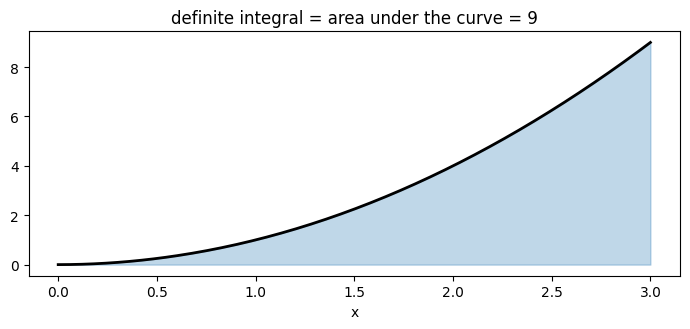

In [7]:
F = sp.integrate(sp.cos(x), x)
print("integral of cos(x) =", F, "  and d/dx of that =", sp.diff(F, x), " (back to cos -> FTC)")
# definite integral = signed area
val = sp.integrate(x**2, (x, 0, 3))
print("area under x^2 from 0 to 3 =", val)
# u-substitution example: integral 2x e^{x^2} dx = e^{x^2}
print("substitution: integral 2x e^(x^2) dx =", sp.integrate(2*x*sp.exp(x**2), x))

xs = np.linspace(0, 3, 200)
plt.figure(figsize=(7,3.4)); plt.plot(xs, xs**2, 'k', lw=2)
plt.fill_between(xs, xs**2, alpha=0.3, color="#2c7bb6")
plt.title(f"definite integral = area under the curve = {val}"); plt.xlabel("x"); plt.tight_layout(); plt.show()

## 5. Taylor series (Calc 2) -- and the repo connection

A function near a point equals the sum of its derivatives:
$f(x)=\sum f^{(k)}(a)/k!\,(x-a)^k$. This is `dgs/taylor.py`, and the same expansion
of the propagation constant $\beta(\omega)$ gives the dispersion the receiver
inverts.

In [8]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import taylor
print("e^x to order 5 :", taylor.taylor_series(sp.exp(x), x, 0, 5))
print("sin x to order 5:", taylor.taylor_series(sp.sin(x), x, 0, 5))
# Euler's formula falls out of the series
print("e^(ix) = cos x + i sin x  (as series):",
      sp.simplify(taylor.taylor_series(sp.exp(sp.I*x), x, 0, 8)
                  - (taylor.taylor_series(sp.cos(x), x, 0, 8) + sp.I*taylor.taylor_series(sp.sin(x), x, 0, 8))) == 0)

e^x to order 5 : x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1
sin x to order 5: x**5/120 - x**3/6 + x
e^(ix) = cos x + i sin x  (as series): True


## Where this lives in physics (so it sticks)

| calculus idea | physics it becomes |
|---|---|
| derivative = rate | velocity $dx/dt$, EMF $=-d\Phi/dt$, current in a capacitor $C\,dV/dt$ |
| chain rule | dispersion $\beta_2=d^2\beta/d\omega^2$, group velocity $d\omega/dk$ |
| integral = total | work $\int F\,dx$, charge $\int I\,dt$, energy under a curve |
| FTC (inverse ops) | why $d/dt$ in time is $\times i\omega$ in frequency (the receiver) |
| Taylor series | the dispersion operator $H(f)=e^{i\pi D f^2}$, small-angle approximations |

Calculus is not a separate subject from your research -- it *is* your research,
written in symbols. Master these five and you have the whole toolkit. Civilian
education.